In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

In [2]:
file_path = 'Country-data.csv'

In [3]:
print("Versao do np", np.__version__)
print("Versao do pandas", pd.__version__)
print("Versao do MatplotLib", plt.matplotlib.__version__)
print("Versao do Seaborn", sns.__version__)

Versao do np 2.3.4
Versao do pandas 2.3.3
Versao do MatplotLib 3.10.7
Versao do Seaborn 0.13.2


In [4]:
import sklearn
print("Versao do Scikit Learn", sklearn.__version__)

Versao do Scikit Learn 1.7.2


In [5]:
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "rohan0301/unsupervised-learning-on-country-data",
  file_path,
)
print("First 5 records:", df.head())

First 5 records:                country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  


In [27]:
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score

               country  child_mort   exports    health   imports    income  \
0          Afghanistan    0.426485  0.049482  0.358608  0.257765  0.008047   
1              Albania    0.068160  0.139531  0.294593  0.279037  0.074933   
2              Algeria    0.120253  0.191559  0.146675  0.180149  0.098809   
3               Angola    0.566699  0.311125  0.064636  0.246266  0.042535   
4  Antigua and Barbuda    0.037488  0.227079  0.262275  0.338255  0.148652   

   inflation  life_expec  total_fer      gdpp  
0   0.126144    0.475345   0.736593  0.003073  
1   0.080399    0.871795   0.078864  0.036833  
2   0.187691    0.875740   0.274448  0.040365  
3   0.245911    0.552268   0.790221  0.031488  
4   0.052213    0.881657   0.154574  0.114242  


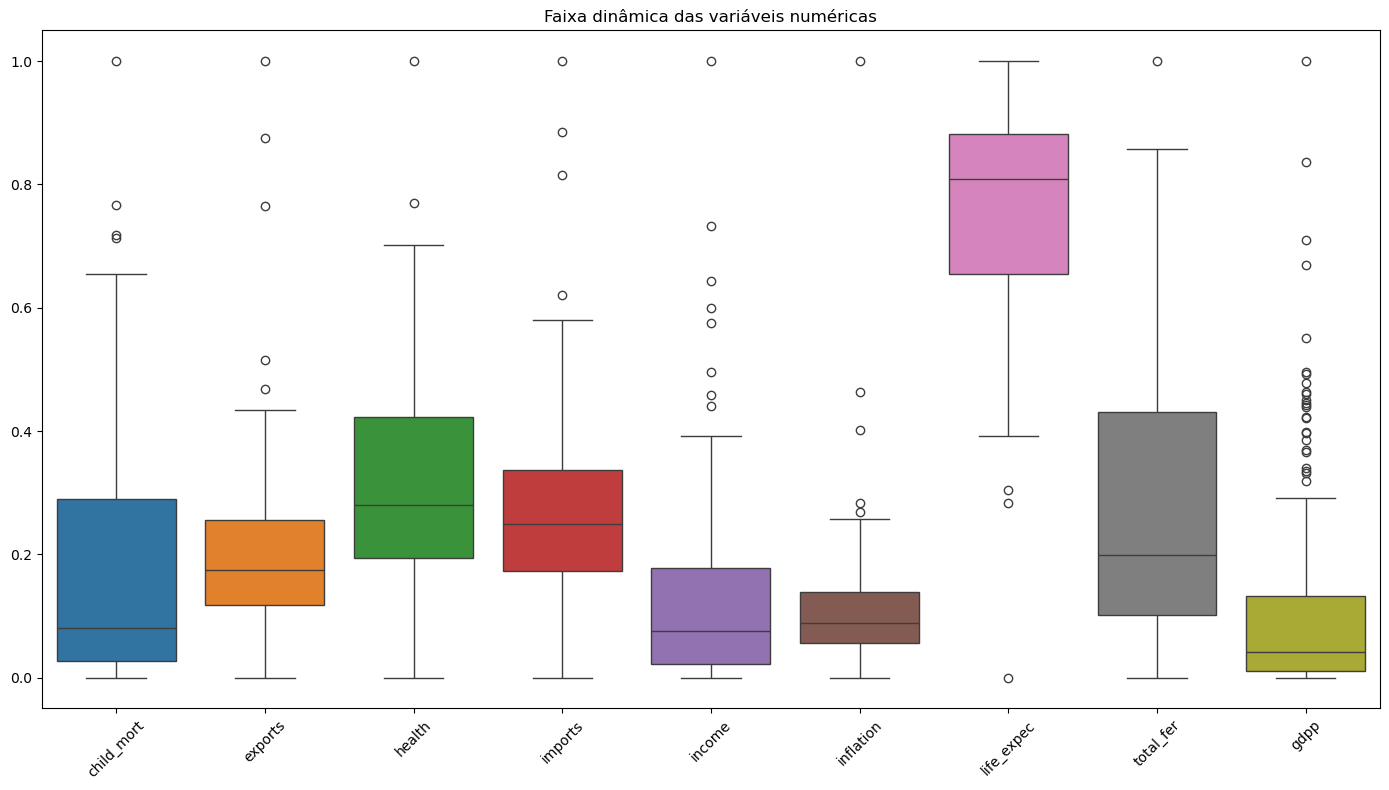

In [7]:
numeric_cols = df.columns.drop('country')

from sklearn.preprocessing import MinMaxScaler
# Instanciar o normalizador
# Testado com MinMaxScaler e StandardScaler. Novamente MinMaxScaler apresentou melhores resultados visuais.
scaler = MinMaxScaler()

# Aplicar a normalização
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Verificar o resultado
print(df_scaled.head())

plt.figure(figsize=(14, 8))
sns.boxplot(data=df_scaled[numeric_cols])
plt.xticks(rotation=45)
plt.title('Faixa dinâmica das variáveis numéricas')
plt.tight_layout()
plt.show()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


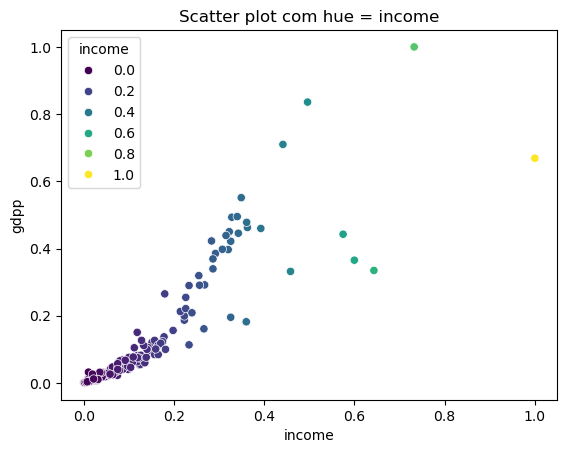

In [8]:
df.info()
# Dessa vez usando os valores de Income e Inflation normalizados e sem PCA
sns.scatterplot(data=df_scaled, x="income", y="gdpp", hue="income", palette="viridis")
plt.title("Scatter plot com hue = income")
plt.show()

In [9]:
from sklearn.decomposition import PCA
X = df_scaled.select_dtypes(include=['float64', 'int64'])

# Aplicar PCA para reduzir a dimensionalidade para 2 componentes principais
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.55001227 0.13384784]


In [10]:
# Inicializando o KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_pca)
kmeans.fit(X_pca)
kmeans

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


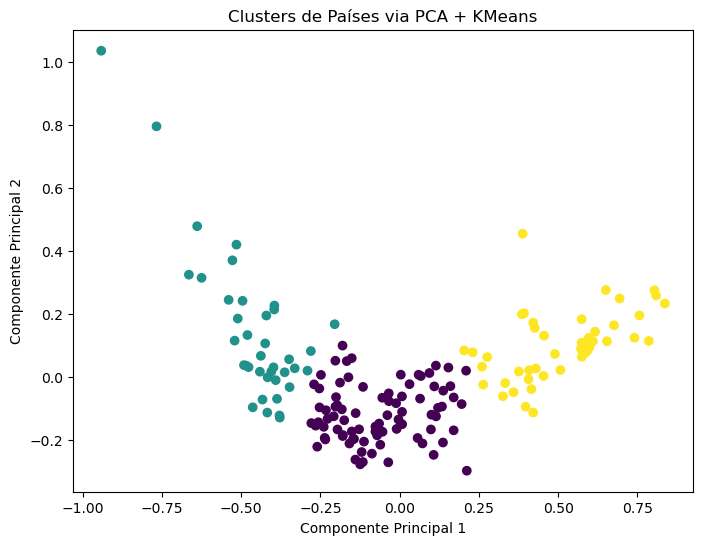

In [11]:
# 5. Visualização dos clusters formados usando PCA para redução de dimensionalidade
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Clusters de Países via PCA + KMeans")
plt.show()

In [12]:
print("Silhouette Score:", silhouette_score(X_pca, kmeans.labels_))
print("Davies-Bouldin Score:", davies_bouldin_score(X_pca, kmeans.labels_))
print("Calinski-Harabasz Score:", calinski_harabasz_score(X_pca, kmeans.labels_))
print("WSS:", kmeans.inertia_)

Silhouette Score: 0.5002894038198847
Davies-Bouldin Score: 0.6872840612262077
Calinski-Harabasz Score: 265.0286048832189
WSS: 6.915866690535985


Aqui vemos que O WSS teve um valor baixo indicando que os clusters sao compactos e homogêneos. O valor acima de 0.5 do Silhouette Score indica uma separaçao razoável entre clusters.

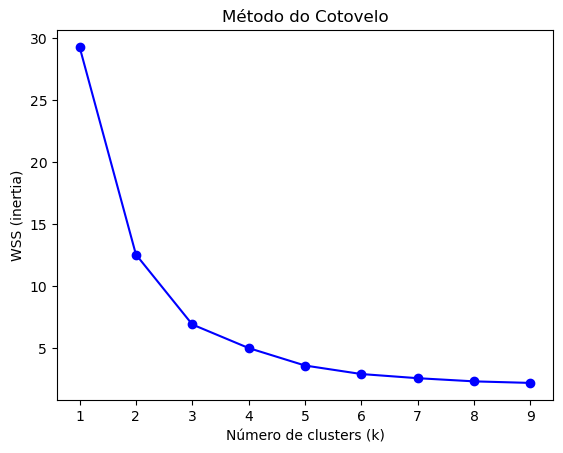

In [13]:
wss = []
K = range(1, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)  # dados já escalados
    wss.append(kmeans.inertia_)  # inertia_ = WSS

plt.plot(K, wss, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('WSS (inertia)')
plt.title('Método do Cotovelo')
plt.show()

#Aplicando o método do cotovelo para determinar o número ideal de clusters (3 parece adequado)

In [14]:
wss_list = []
si_list = []
dbi_list = []
chi_list = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)

    wss_list.append(kmeans.inertia_)
    si_list.append(silhouette_score(X_pca, kmeans.labels_))
    dbi_list.append(davies_bouldin_score(X_pca, kmeans.labels_))
    chi_list.append(calinski_harabasz_score(X_pca, kmeans.labels_))

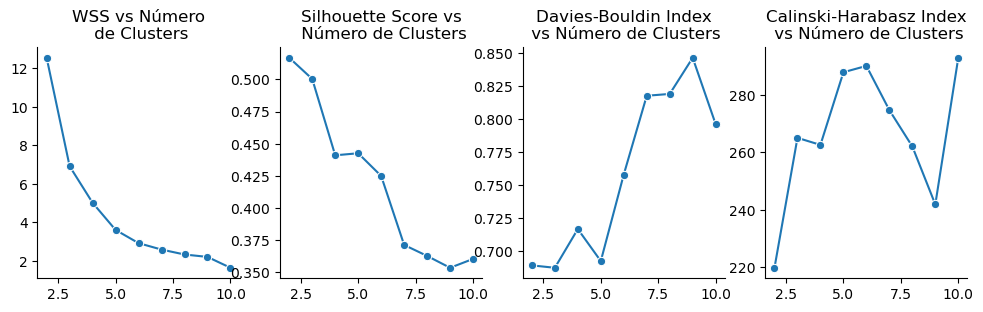

In [ ]:
f, ax = plt.subplots(1, 4, figsize=(12, 3))
sns.lineplot(x=range(2, 11), y=wss_list, marker='o', ax=ax[0])
ax[0].set_title('WSS vs Número\n de Clusters')
sns.lineplot(x=range(2, 11), y=si_list, marker='o', ax=ax[1])
ax[1].set_title('Silhouette Score vs\n Número de Clusters')
sns.lineplot(x=range(2, 11), y=dbi_list, marker='o', ax=ax[2])
ax[2].set_title('Davies-Bouldin Index\n vs Número de Clusters')
sns.lineplot(x=range(2, 11), y=chi_list, marker='o', ax=ax[3])
ax[3].set_title('Calinski-Harabasz Index\n vs Número de Clusters')

sns.despine()
plt.show()

# Davies-Bouldin Index menor indica melhor separação entre clusters. Este valor diminui até k=3 e depois começa a aumentar, 
# sugerindo que 3 clusters podem ser ideais.

In [16]:
results_df = pd.DataFrame({
    'WSS': wss_list,
    'Silhouette Score': si_list,
    'Davies-Bouldin Index': dbi_list,
    'Calinski-Harabasz Index': chi_list
})

results_df

,WSS,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,12.548418,0.516774,0.689096,219.851344
1,6.915867,0.500289,0.687284,265.028605
2,5.017849,0.440957,0.716652,262.584556
3,3.610168,0.442554,0.692371,287.841371
4,2.924578,0.424904,0.758017,290.048324
5,2.590041,0.371273,0.817735,274.675604
6,2.334743,0.362728,0.819110,262.031928
7,2.209440,0.353522,0.846533,241.877170
8,1.645290,0.360402,0.796146,292.877670


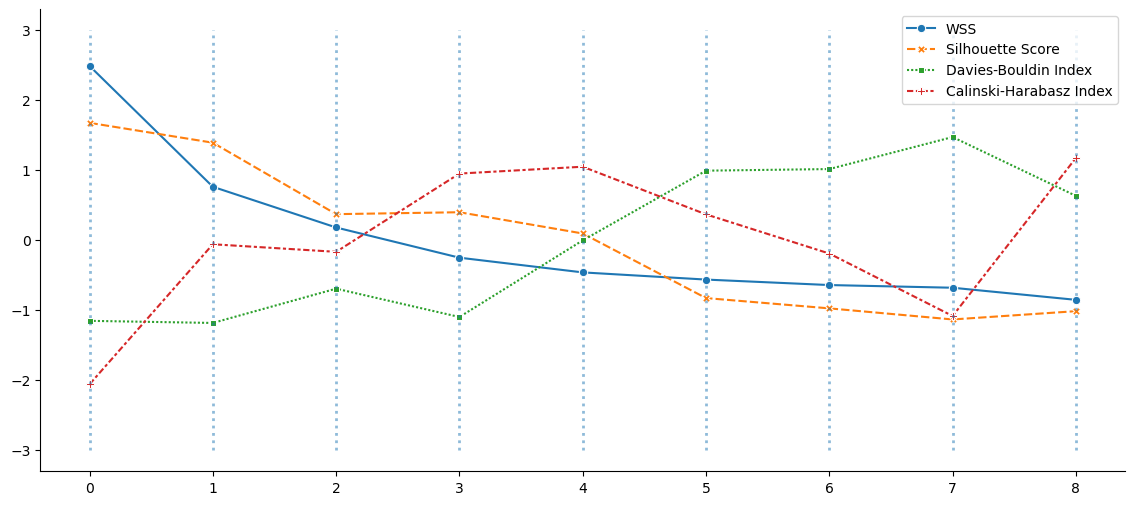

In [17]:
results_scaled_df = StandardScaler().fit_transform(results_df.select_dtypes(include=['float64', 'int64']))
results_scaled_df = pd.DataFrame(results_scaled_df, columns=results_df.columns)
results_scaled_df

f, ax = plt.subplots(figsize=(14,6))
sns.lineplot(data=results_scaled_df, ax=ax, markers=True)

for line in range(0, results_scaled_df.shape[0]):
    ax.vlines(line, ymin=-3, ymax=3, linestyles=':', linewidth=2, alpha=0.5)

plt.grid(False)
sns.despine()
plt.show()

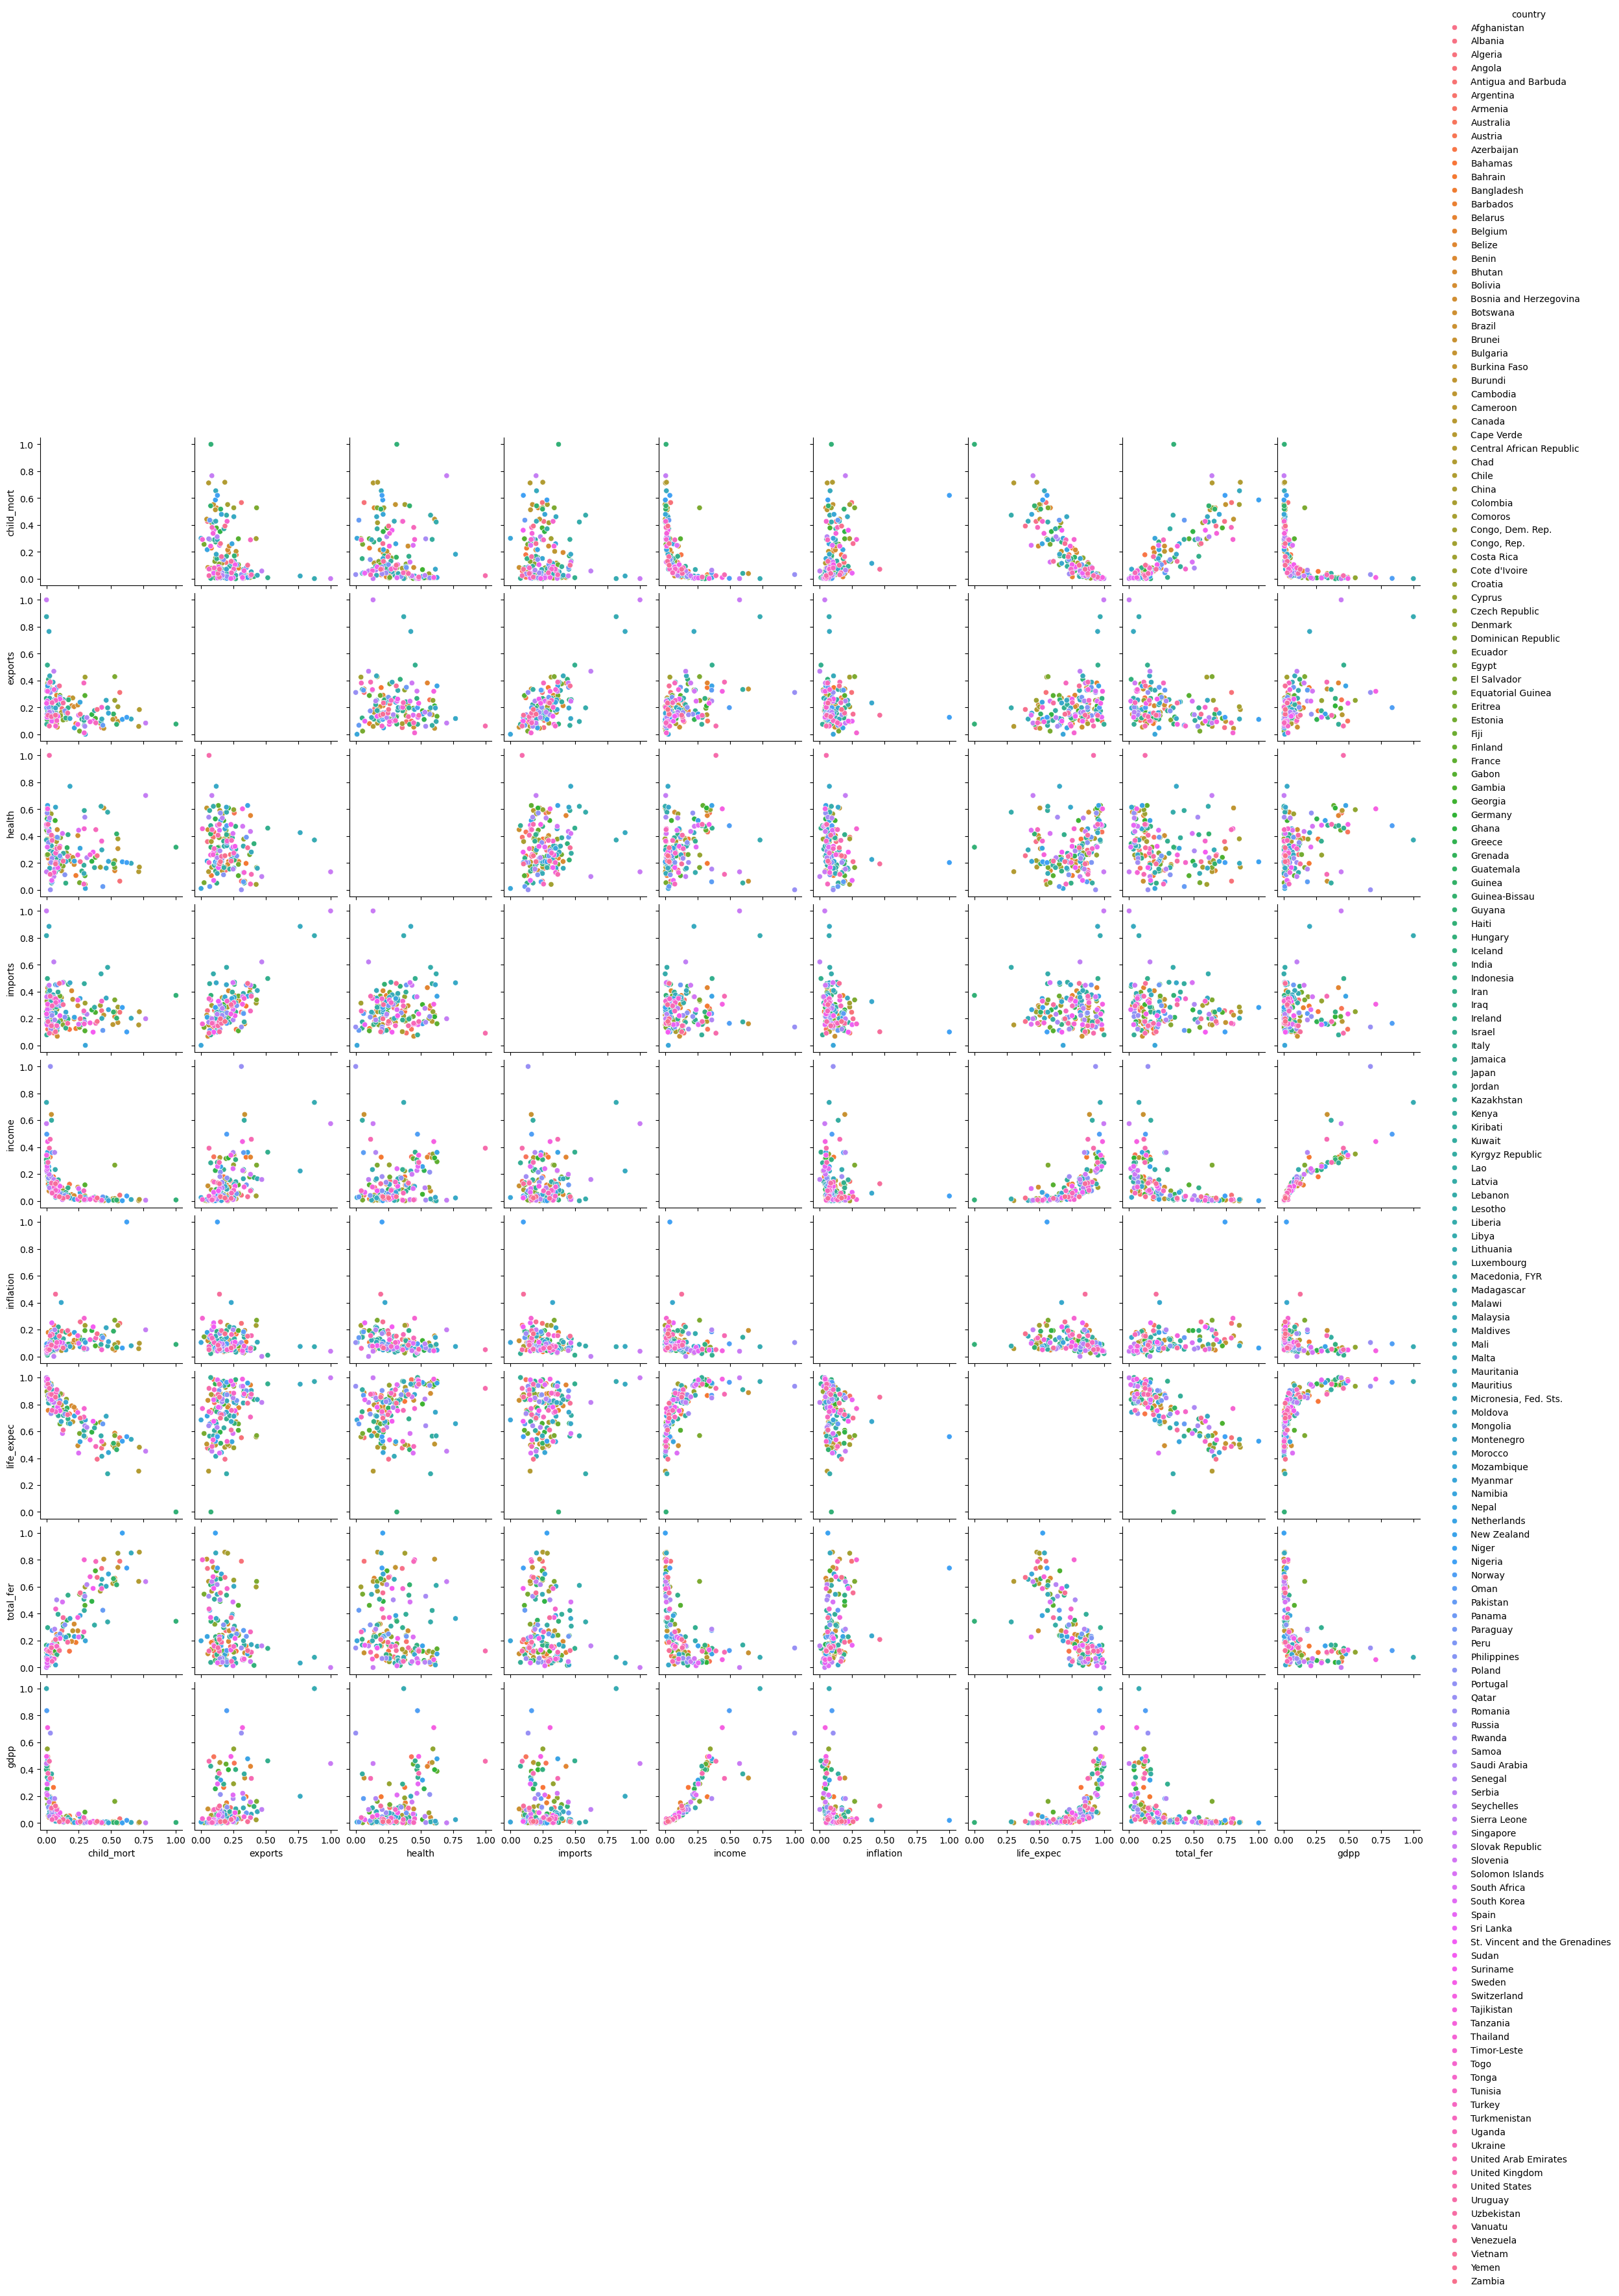

In [18]:
sns.pairplot(df_scaled, hue="country")

For n_clusters = 2, the average silhouette_score is : 0.5167744556201839
For n_clusters = 3, the average silhouette_score is : 0.5002894038198847
For n_clusters = 4, the average silhouette_score is : 0.44095748749105784
For n_clusters = 5, the average silhouette_score is : 0.44255362239736123
For n_clusters = 6, the average silhouette_score is : 0.42490436955439026


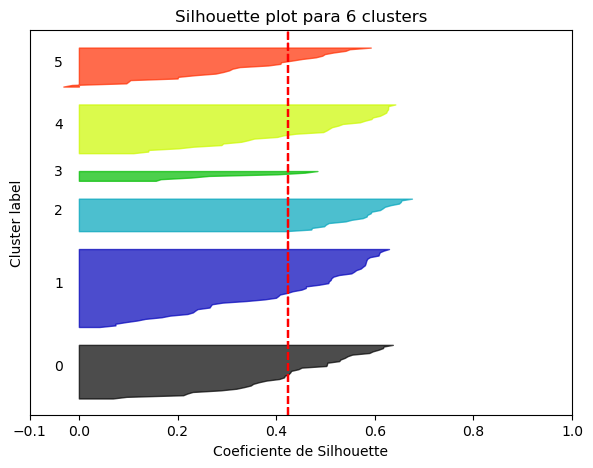

In [19]:
# Análise de Silhueta para diferentes números de clusters

# Conclusao: 3 clusters parecem ser os mais adequados com base na análise de silhueta e nos outros índices avaliados.
# Com base nas quatro métricas, k=3 parece ser o número ideal de clusters.
# Tem o menor DBI
# Tem bom Silhouette Score
# Está no cotovelo do WSS
# Tem um CHI relativamente alto

# Análise de Silhueta
# O valor mais alto está em k=2, mas k=3 ainda é competitivo e oferece melhor interpretação dos dados.
range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(X_pca)

    silhouette_avg = silhouette_score(X_pca, cluster_labels)
    print(f"For n_clusters = {n_clusters}, the average silhouette_score is : {silhouette_avg}")

sample_silhouette_values = silhouette_samples(X_pca, cluster_labels)
import matplotlib.cm as cm
fig, ax1 = plt.subplots(1, 1)
fig.set_size_inches(7, 5)

ax1.set_xlim([-0.1, 1])
ax1.set_ylim([0, len(X_pca) + (n_clusters + 1) * 10])

y_lower = 10
for i in range(n_clusters):
    ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cm.nipy_spectral(float(i) / n_clusters)
    ax1.fill_betweenx(np.arange(y_lower, y_upper),
                        0, ith_cluster_silhouette_values,
                        facecolor=color, edgecolor=color, alpha=0.7)

    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

    y_lower = y_upper + 10  

    ax1.set_title(f"Silhouette plot para {n_clusters} clusters")
    ax1.set_xlabel("Coeficiente de Silhouette")
    ax1.set_ylabel("Cluster label")

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
plt.show()

In [20]:
from sklearn import metrics

scores = [
    ('V-Measure', metrics.v_measure_score),
    ('Rand Index', metrics.rand_score),
    ('Adjusted Rand Index', metrics.adjusted_rand_score),
    ('Mutual Information Score', metrics.mutual_info_score),
    ('Adjusted Mutual Information Score', metrics.adjusted_mutual_info_score),
    ('Normalized Mutual Information Score', metrics.normalized_mutual_info_score)
]

In [21]:
country_kmeans = KMeans(n_clusters=3, random_state=42).fit(X_pca)

In [22]:
for score_name, score_func in scores:
    score_value = score_func(df['country'], country_kmeans.labels_)
    print(f"{score_name}: {score_value}")

V-Measure: 0.3366535136731279
Rand Index: 0.6263617343626001
Adjusted Rand Index: 0.0
Mutual Information Score: 1.0358579009670237
Adjusted Mutual Information Score: -2.2627996140385887e-14
Normalized Mutual Information Score: 0.33665351367312796


In [42]:
algorithms = {
    'KMeans': KMeans(n_clusters=3, random_state=42),
    'DBSCAN': DBSCAN(eps=0.5, min_samples=5),
    'AgglomerativeClustering': AgglomerativeClustering(n_clusters=3)
}

In [ ]:
cluster_labels = {}
for name, algorithm in algorithms.items():
    labels = algorithm.fit_predict(X_pca)
    cluster_labels[name] = labels
    ari = metrics.adjusted_rand_score(df['country'], labels)
    nmi = metrics.normalized_mutual_info_score(df['country'], labels)
    ami = metrics.adjusted_mutual_info_score(df['country'], labels)
    print(f"{name} - ARI: {ari}, NMI: {nmi}, AMI: {ami}")

# Conclusao: KMeans apresentou os melhores resultados em todas as métricas avaliadas, 
# seguido por AgglomerativeClustering. DBSCAN teve desempenho inferior, possivelmente devido 
# à sua sensibilidade aos parâmetros eps e min_samples.
#
# Mesmo ajustando o valor do eps do DBSCAN, os resultados não melhoraram significativamente.

# AglomerativeClustering apresentou resultados parecidos ao KMeans, mas ainda assim inferiores 
# em todas as métricas e estruturalmente não corresponde aos rótulos reais.

# Os algoritmos de clustering não supervisionado não apresentaram alta concordância com os rótulos 
# de país, sugerindo que a estrutura latente dos dados é guiada por características transversais aos 
# países, e não por fronteiras geográficas.

# Isso explica perfeitamente:
#   Baixa homogeneidade
#   Completude alta
#   Clusters visualmente coerentes, mas semanticamente desalinhados

KMeans - ARI: 0.0, NMI: 0.33665351367312796, AMI: -2.2627996140385887e-14
DBSCAN - ARI: 0.0, NMI: 0.0, AMI: 0.0
AgglomerativeClustering - ARI: 0.0, NMI: 0.3396838488740519, AMI: -1.0581593548731412e-14


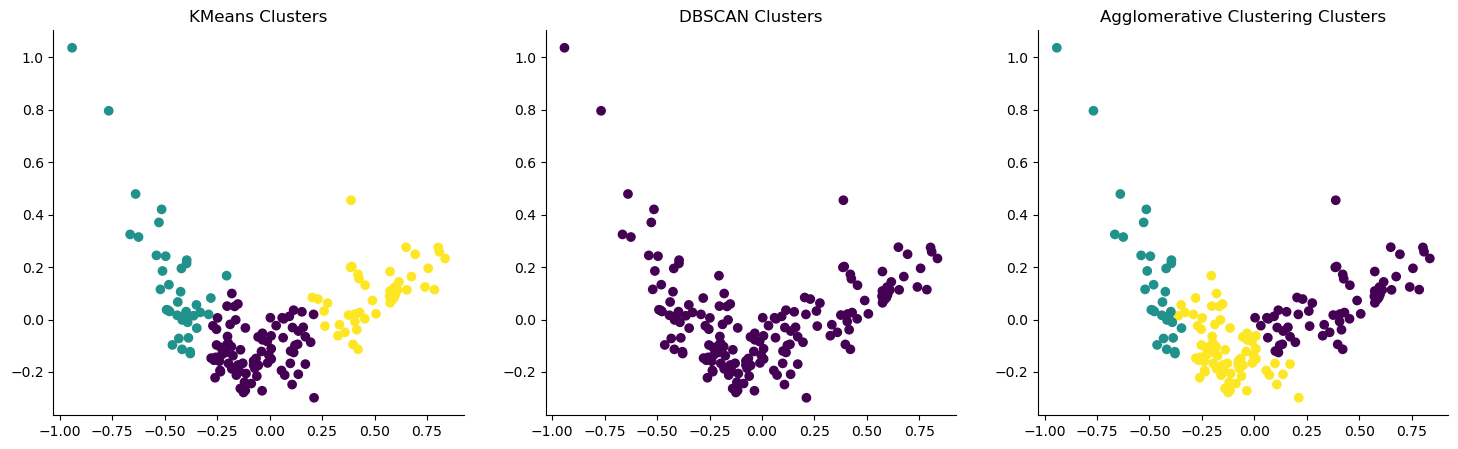

In [54]:
f, ax = plt.subplots(1, 3, figsize=(18, 5))

ax[0].scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels['KMeans'], cmap='viridis')
ax[0].set_title('KMeans Clusters')
ax[1].scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels['DBSCAN'], cmap='viridis')
ax[1].set_title('DBSCAN Clusters')
ax[2].scatter(X_pca[:,0], X_pca[:,1], c=cluster_labels['AgglomerativeClustering'], cmap='viridis')
ax[2].set_title('Agglomerative Clustering Clusters')

sns.despine()
plt.show()

In [58]:
results = {}
for algorithm_name, label in cluster_labels.items():
    results[algorithm_name] = {
        'homogeneidade': metrics.homogeneity_score(df['country'], label),
        'Completude': metrics.completeness_score(df['country'], label),
        'v_measure': metrics.v_measure_score(df['country'], label)
    }


In [59]:
print(pd.DataFrame(results).T)

                         homogeneidade  Completude  v_measure
KMeans                        0.202395         1.0   0.336654
DBSCAN                        0.000000         1.0   0.000000
AgglomerativeClustering       0.204590         1.0   0.339684


In [60]:
from scipy.cluster.hierarchy import dendrogram, linkage

Text(0.5, 1.0, 'Dendrograma - Single Linkage')

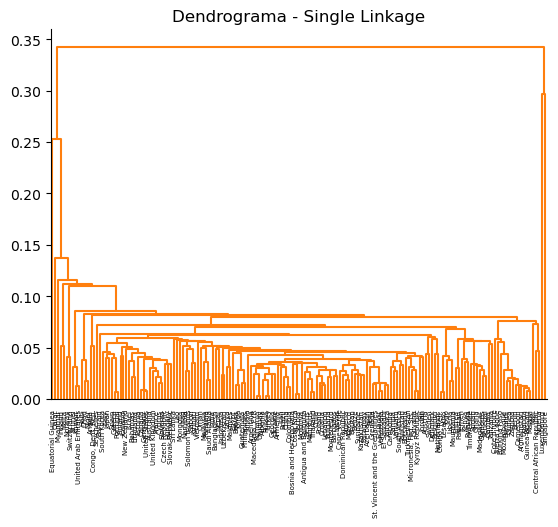

In [80]:
single_linkage = linkage(X_pca, method='single', metric='euclidean')

dendrogram(
    single_linkage,
    labels=df['country'].values,
    orientation='top',
    color_threshold=0.5,
    distance_sort='true'
)
sns.despine()
plt.title("Dendrograma - Single Linkage")

# Agrupamentos razoáveis, mas menos fiéis às distâncias reais

Text(0.5, 1.0, 'Dendrograma - Complete Linkage')

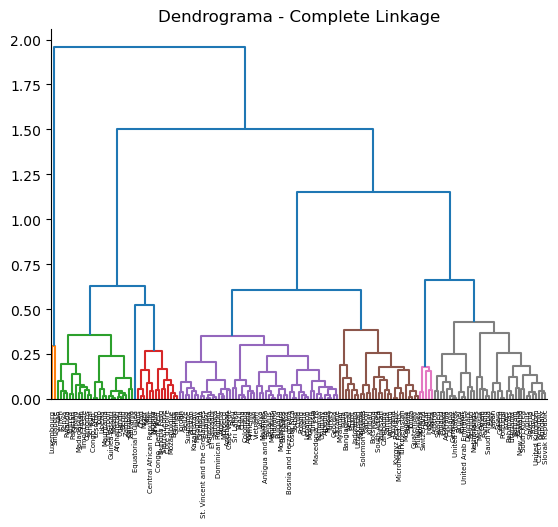

In [81]:
complete_linkage = linkage(X_pca, method='complete', metric='euclidean')

dendrogram(
    complete_linkage,
    labels=df['country'].values,
    orientation='top',
    color_threshold=0.5,
    distance_sort='true'
)
sns.despine()
plt.title("Dendrograma - Complete Linkage")

# Complete Linkage

# Clusters mais compactos, porém com menor separação entre grupos
# O complete linkage tende a formar clusters mais compactos, o que combina bem com essa escolha.
#
# Com base nos quatro critérios, k = 3 aparece como uma escolha equilibrada:
#   Boa separação (Silhouette)
#   Boa compactação (WSS)
#   Baixa sobreposição (Davies-Bouldin)
#   Alta variância entre clusters (Calinski-Harabasz)

Text(0.5, 1.0, 'Dendrograma - Average Linkage')

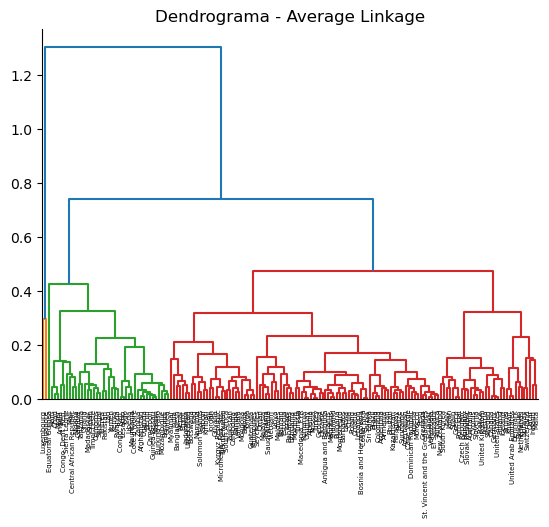

In [82]:
average_linkage = linkage(X_pca, method='average', metric='euclidean')

dendrogram(
    average_linkage,
    labels=df['country'].values,
    orientation='top',
    color_threshold=0.5,
    distance_sort='true'
)
sns.despine()
plt.title("Dendrograma - Average Linkage")

# Melhor representação das distâncias e agrupamentos equilibrados
# Apesar de ter a melhor correlação cophenética, o complete linkage representou melhor os clusters.

In [ ]:
#### Determinando os parâmetros EPS e Min Samples para o DBSCAN ####

min_samples = 4  # Geralmente entre 3 e 5

# Heurísticas:
# 1 -> d <= 2 -> min_samples = 4
# 2 -> d > 2 -> min_samples = 2*d
# 3 -> n >= 1000 -> min_samples = log n(n)
# 4 -> testar valores entre [3, 2*d]

In [86]:
int(np.log(X_pca.shape[0]))

5

In [87]:
# min_samples baseado na 4a heurística
for i in range(3, (2*X_pca.shape[1] + 1), 1):
    print(i)

3
4


In [ ]:
# Escolher min_sample com validação baseada no Silhouette Score, Davies-Bouldin Index e Calinski-Harabasz Index

min_sample_range = range(3, (2*X_pca.shape[1] + 1), 1)
best_min_sample = None
best_score = -1

for min_samples in min_sample_range:
    dbscan_model = DBSCAN(eps=0.2, min_samples=min_samples).fit(X_pca)
    labels = dbscan_model.labels_

    # Evita casos com apenas um cluster
    if len(set(labels)) > 1:
        score = silhouette_score(X_pca, labels)
        best_score = score
        best_min_sample = min_samples

print(f"Melhor min_samples: {best_min_sample} com Silhouette Score: {best_score}")

0.5520614794294394
0.5520614794294394
Melhor min_samples: 4 com Silhouette Score: 0.5520614794294394


In [ ]:
# Calculando distâncias entre os pontos para o melhor min_samples encontrado

from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=(best_min_sample - 1)).fit(X_pca)
distances, indices = neighbors.kneighbors(X_pca)
distances

array([[0.        , 0.01292854, 0.02062284],
       [0.        , 0.01822682, 0.02064807],
       [0.        , 0.01885404, 0.0268094 ],
       [0.        , 0.05135886, 0.11503894],
       [0.        , 0.02599218, 0.03020014],
       [0.        , 0.03255486, 0.03384349],
       [0.        , 0.03265906, 0.03876499],
       [0.        , 0.03024659, 0.03590532],
       [0.        , 0.04420666, 0.07091235],
       [0.        , 0.03722441, 0.03776638],
       [0.        , 0.02128385, 0.04356955],
       [0.        , 0.06324954, 0.07351604],
       [0.        , 0.04906532, 0.0505483 ],
       [0.        , 0.02225139, 0.02788585],
       [0.        , 0.01965175, 0.02198662],
       [0.        , 0.04398999, 0.05838744],
       [0.        , 0.02470824, 0.02491694],
       [0.        , 0.01391932, 0.01807764],
       [0.        , 0.02844461, 0.04273001],
       [0.        , 0.01323003, 0.02789856],
       [0.        , 0.03436495, 0.0365062 ],
       [0.        , 0.03986224, 0.05667409],
       [0.

In [97]:
# Ordenando as distâncias para o gráfico de cotovelo

k_distances = np.sort(distances[:,-1])
k_distances

array([0.00839027, 0.0105814 , 0.01292854, 0.01305417, 0.01558391,
       0.01558391, 0.01575285, 0.01576732, 0.01578952, 0.01578952,
       0.0170469 , 0.01769211, 0.01807764, 0.01822682, 0.01965175,
       0.02036165, 0.02062284, 0.02062284, 0.02064807, 0.02064807,
       0.02152055, 0.02161791, 0.02198662, 0.02198662, 0.02240038,
       0.02240038, 0.02293528, 0.02301405, 0.02372654, 0.02470824,
       0.02474003, 0.02474557, 0.02484221, 0.02484221, 0.02491694,
       0.02591988, 0.0265713 , 0.0265713 , 0.02679512, 0.02679512,
       0.0268094 , 0.02703473, 0.02788585, 0.02788585, 0.02789856,
       0.02789856, 0.02844461, 0.02863919, 0.02868408, 0.03006982,
       0.03020014, 0.03044187, 0.0305906 , 0.03108063, 0.03113767,
       0.0311623 , 0.03127964, 0.03144163, 0.03196228, 0.03268912,
       0.03333854, 0.03384349, 0.0338604 , 0.03418628, 0.03436495,
       0.03442536, 0.03445593, 0.03537711, 0.03547235, 0.03590532,
       0.03596502, 0.03647032, 0.0365062 , 0.03676356, 0.03718

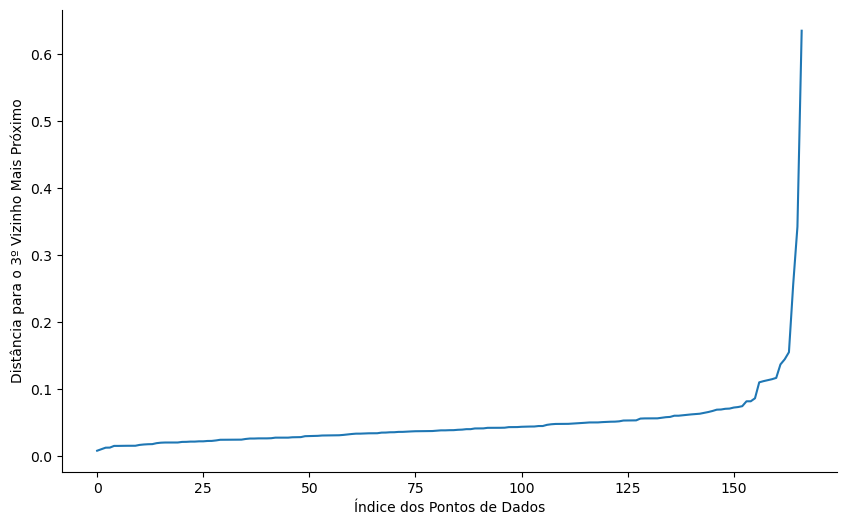

In [98]:
f, ax = plt.subplots(figsize=(10, 6))

ax.plot(k_distances)

ax.set_xlabel('Índice dos Pontos de Dados')
ax.set_ylabel(f'Distância para o {best_min_sample - 1}º Vizinho Mais Próximo')

sns.despine()
plt.show()

In [108]:
from kneed import KneeLocator

x, y = range(len(k_distances)), k_distances

# Funcionou apenas com Convexo. Concavo os valores ficaram zerados mostrando que a curva é para cima
kneedle = KneeLocator(x, y, curve='convex', direction='increasing')

print(round(kneedle.knee, 3))
print(round(kneedle.elbow, 3))

kneedle.knee
eps = k_distances[int(kneedle.knee)]
print(f"Valor sugerido para EPS: {eps}")

160
160
Valor sugerido para EPS: 0.11699651969920705


In [136]:
dbscan_model = DBSCAN(eps=eps, min_samples=best_min_sample).fit(X_pca)
labels = dbscan_model.labels_

sil = silhouette_score(X_pca, labels)
print(f"Silhouette Score do DBSCAN com eps={eps} e min_samples={best_min_sample}: {sil}")

# Interpretação do Resultado

#    Silhouette Score = 0.501:
#        Acima de 0.5 já indica boa separação entre clusters.
#        Os grupos formados são coerentes e bem definidos.
#        Melhor que muitos resultados com K-Means ou Agglomerative em dados brutos.

#    eps = 0.117 e min_samples = 4:
#        Esses parâmetros foram otimizados com base na curva de distância.
#        Isso evita agrupamentos artificiais ou excesso de ruído.

Silhouette Score do DBSCAN com eps=0.11699651969920705 e min_samples=4: 0.5012091974135483


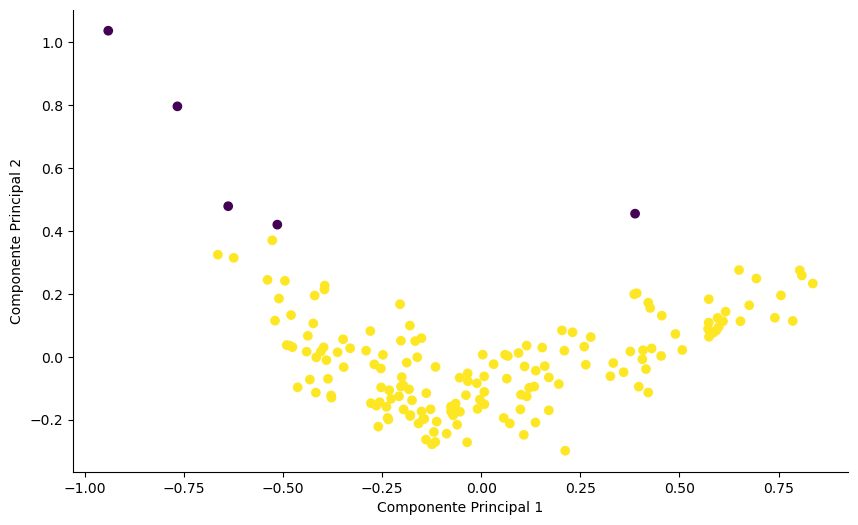

In [138]:
f, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis')

ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')

sns.despine()
plt.show()

In [ ]:
print(f'Número de clusters formados pelo DBSCAN: {len(set(labels)) - (1 if -1 in labels else 0)}')
print(f'Número de pontos considerados ruído: {list(labels).count(-1)}')

# Diagnóstico
#    O gráfico comparativo entre KMeans, Agglomerative e DBSCAN mostra que:
#        KMeans e Agglomerative conseguem formar 3 clusters distintos.
#        DBSCAN está subestimando a densidade — ou seja, o eps está muito pequeno para capturar os grupos, mas mesmo com valores
#        maiores, o número de clusters não aumenta significativamente.

Número de clusters formados pelo DBSCAN: 1
Número de pontos considerados ruído: 5


In [143]:
eps_values = np.linspace(0.05, 0.3, 6)
min_samples_values = range(3, (2*X_pca.shape[1] + 1), 1)

print(f'Eps values: {eps_values}')
print(f'Min samples values: {min_samples_values}')

Eps values: [0.05 0.1  0.15 0.2  0.25 0.3 ]
Min samples values: range(3, 5)


In [147]:
param_grid = []

for eps in eps_values:
    for min_samples in min_samples_values:
        param_grid.append({'eps': eps, 'min_samples': min_samples})

print(f'Número total de combinações de parâmetros: {len(param_grid)}')

Número total de combinações de parâmetros: 12


In [ ]:
best_params = None
best_score = -1

for param in param_grid:

    eps = param['eps']
    min_samples = param['min_samples']

    dbscan_model = DBSCAN(eps=eps, min_samples=min_samples).fit(X_pca)
    labels = dbscan_model.labels_

    # Evita casos com apenas um cluster
    if len(set(labels)) > 1:
        score = silhouette_score(X_pca, labels)
        
        print('min_samples', min_samples)
        print('eps', eps)
        print('score', score)
        print('---')

        if score > best_score:
            best_score = score
            best_params = param

# eps = 0.15 com min_samples = 3 ou 4 gerou:

#    Silhouette Score acima de 0.52, o que é excelente. Separação clara entre grupos.

# eps = 0.3 com min_samples = 4 chegou a 0.61 de Silhouette, mas pode estar formando mais de 3 clusters ou agrupando demais.

min_samples 3
eps 0.05
score 0.06612091501376695
---
min_samples 4
eps 0.05
score 0.004782506160628862
---
min_samples 3
eps 0.1
score 0.44003999854996695
---
min_samples 4
eps 0.1
score 0.44003999854996695
---
min_samples 3
eps 0.15000000000000002
score 0.5520614794294394
---
min_samples 4
eps 0.15000000000000002
score 0.5274793699870758
---
min_samples 3
eps 0.2
score 0.5520614794294394
---
min_samples 4
eps 0.2
score 0.5520614794294394
---
min_samples 3
eps 0.25
score 0.5520614794294394
---
min_samples 4
eps 0.25
score 0.5520614794294394
---
min_samples 3
eps 0.3
score 0.6138727963267735
---
min_samples 4
eps 0.3
score 0.6138727963267735
---


In [151]:
dbscan_model = DBSCAN(eps=best_params['eps'], min_samples=best_params['min_samples']).fit(X_pca)
labels = dbscan_model.labels_

sil = silhouette_score(X_pca, labels)
print(f"Silhouette Score do DBSCAN com eps={eps} e min_samples={best_min_sample}: {sil}")

Silhouette Score do DBSCAN com eps=0.3 e min_samples=4: 0.6138727963267735


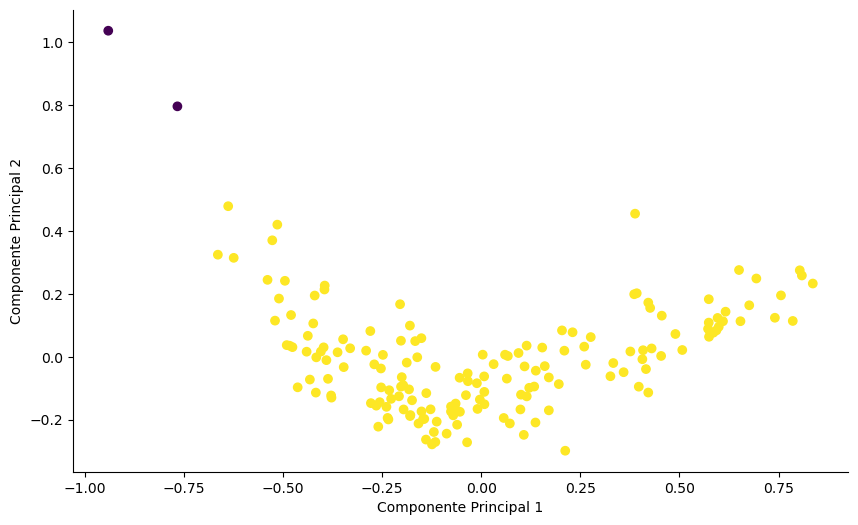

In [ ]:
f, ax = plt.subplots(figsize=(10, 6))

ax.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis')

ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')

sns.despine()
plt.show()

# Silhouette alto diferente de múltiplos clusters: um único cluster bem compacto pode gerar um bom score, 
# mas não significa que há separação entre grupos.

# O gráfico mostra pouca variação de densidade entre os grupos — o que dificulta a ação do DBSCAN.
# DBSCAN depende de diferenças claras de densidade local para separar clusters. Se os dados estão 
# uniformemente distribuídos (como após PCA), ele tende a formar um único grupo grande.